In [22]:
# Import Packages
import inspect
from mpi4py import MPI
from petsc4py.PETSc import ScalarType, InsertMode, ScatterMode
import numpy as np

# FEniCSx Packages
import basix.ufl
import dolfinx
from dolfinx import plot
from dolfinx.fem.petsc import assemble_matrix, assemble_vector
import ufl
from ufl import (
    jump, avg, inner, dot, grad, outer, FacetNormal, CellDiameter
)

# Mesh Generation Functions
def edge_mesh(v0, v1, N):
    """Generates N nodes from vertex 0 to vertex 1"""
    nodes = np.zeros((N, 3), dtype=np.float64)
    nodes[:,0] = np.linspace(v0[0], v1[0], N)
    nodes[:,1] = np.linspace(v0[1], v1[1], N)
    nodes[0,2] = v0[2]
    nodes[-1,2] = v1[2]
    if v0[2] == 1:
        return nodes[1:,:]
    return nodes

def assemble_graph_mesh(vertices, edge_connections, N, comm):
    if comm.rank == 0:
        nodes = np.zeros((0, 3), dtype=np.float64)
        connectivity = np.zeros((0, 2), dtype=np.int64)
        for i in range(edge_connections.shape[0]):
            v0 = vertices[edge_connections[i, 0],:]
            v1 = vertices[edge_connections[i, 1],:]
            new_nodes = edge_mesh(v0, v1, N)
            nodes = np.concatenate((nodes, new_nodes))
        vertex_ids = np.where(nodes[:,2] != 0)[0]
        for i in range(edge_connections.shape[0]):
            if i == 0:
                v0 = vertex_ids[edge_connections[i, 0]]
                v1 = vertex_ids[edge_connections[i, 1]]
                local_connectivity_array = np.repeat(np.arange(v0, v1+1), 2)[1:-1]
                connectivity = np.concatenate((connectivity, local_connectivity_array.reshape(N-1, 2)))
            else:
                v0 = vertex_ids[edge_connections[i, 0]]
                v1 = vertex_ids[edge_connections[i, 1]]
                v_prev = vertex_ids[edge_connections[i-1, 1]]
                local_connectivity_array = np.repeat(np.arange(v_prev, v1+1), 2)[1:-1]
                local_connectivity_array[0] = v0
                connectivity = np.concatenate((connectivity, local_connectivity_array.reshape(N-1, 2)))
    else:
        nodes = np.zeros((0, 2), dtype=np.float64)
        connectivity = np.zeros((0, 2), dtype=np.int64)
    return nodes, connectivity

comm = MPI.COMM_WORLD
N = 4

vertices = np.array([
    [0, 0, 2],
    [0, 1, 1],
    [-1, 2, 2],
    [1, 2, 2]])

edges = np.array([
    [0, 1],
    [1, 2],
    [1, 3]
])

nodes_type, connectivity = assemble_graph_mesh(vertices, edges, N, comm)
nodes = nodes_type[:,:2]

# Coordinate element must be vector-valued with same dimension as node coordinates
c_el = ufl.Mesh(
    basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(nodes.shape[1],))
)

sig = inspect.signature(dolfinx.mesh.create_cell_partitioner)
kwargs = {}

if "max_facet_to_cell_links" in list(sig.parameters.keys()):
    kwargs["max_facet_to_cell_links"] = 3

graph_mesh = dolfinx.mesh.create_mesh(
    comm,
    cells=connectivity,
    x=nodes,
    e=c_el,
    partitioner=dolfinx.mesh.create_cell_partitioner(
        dolfinx.mesh.GhostMode.shared_facet, **kwargs
    ),
    **kwargs
)

# Identify Bifrucation Nodes
bifrucation_node_ids = np.where(nodes_type[:,2]==1)[0]
bifrucation_node_list = nodes[bifrucation_node_ids]
num_bifrucation_nodes = bifrucation_node_list.shape[0]
bifrucation_node_list = np.concatenate((bifrucation_node_list, np.zeros((num_bifrucation_nodes, 1))), axis=1)

def bifrucation_nodes(x, y=bifrucation_node_list):
    return np.isclose(x[0], 1)

# Create Submesh on Bifrucation Nodes
tdim = graph_mesh.topology.dim
fdim = tdim - 1
graph_mesh.topology.create_connectivity(fdim, fdim)

bifrucation_cells = dolfinx.mesh.locate_entities(
    graph_mesh, fdim, bifrucation_nodes
)

bifrucation_node_mesh, entity_map, vertex_map, geom_map = dolfinx.mesh.create_submesh(
    graph_mesh, fdim, bifrucation_cells
)


In [16]:
import numpy as np, sys, traceback
print("nodes shape, dtype:", nodes.shape, getattr(nodes, "dtype", None))
print("connectivity shape, dtype:", connectivity.shape, getattr(connectivity, "dtype", None))
print("connectivity sample (first 20):", connectivity.flatten()[:20])
try:
    print("connectivity min/max:", np.min(connectivity), np.max(connectivity))
except Exception as e:
    print("connectivity min/max failed:", e)
print("nodes_type shape:", nodes_type.shape)
print("c_el type:", type(c_el), repr(c_el)[:200])
print("graph_mesh creation call uses connectivity dtype:", connectivity.dtype)
# Basic validations
if connectivity.size > 0:
    nv = nodes.shape[0]
    if np.min(connectivity) < 0 or np.max(connectivity) >= nv:
        print('ERROR: connectivity indices out of range for nodes (0..{})'.format(nv-1))
else:
    print('WARNING: connectivity is empty')

nodes shape, dtype: (10, 2) float64
connectivity shape, dtype: (9, 2) int64
connectivity sample (first 20): [0 1 1 2 2 3 3 4 4 5 5 6 3 7 7 8 8 9]
connectivity min/max: 0 9
nodes_type shape: (10, 3)
c_el type: <class 'ufl.domain.Mesh'> Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 5)
graph_mesh creation call uses connectivity dtype: int64


[1 1 2 2 2 1 1 1 1]


/tmp/ipykernel_313044/2251197181.py:30: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


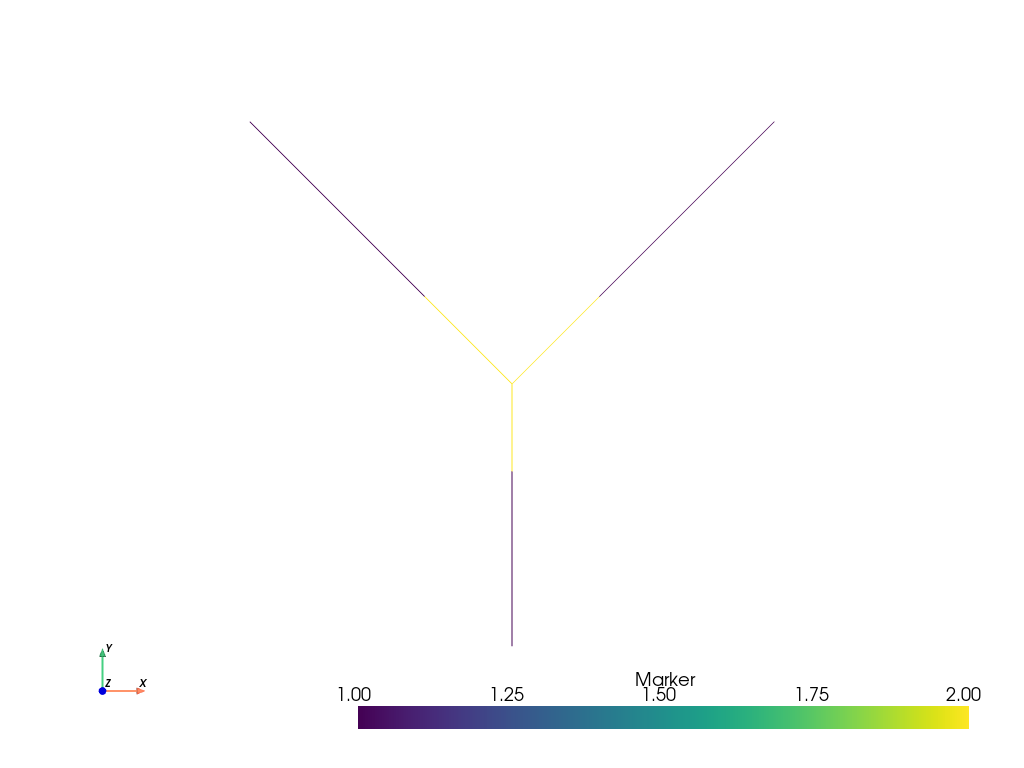

In [ ]:
import pyvista

# Create Marker for Bifrucation Nodes
tdim = graph_mesh.topology.dim
cell_map = graph_mesh.topology.index_map(tdim)
num_cells = cell_map.size_local + cell_map.num_ghosts
all_cells = np.arange(num_cells, dtype=np.int32)
marker = np.ones(num_cells, dtype=np.int32)
marker[2:5] = 2

print(marker)

# Create Meshtag to mark bifruncation nodes
cell_tag = dolfinx.mesh.meshtags(graph_mesh, tdim, all_cells, marker)

cells, types, x = plot.vtk_mesh(graph_mesh)

grid = pyvista.UnstructuredGrid(cells, types, x)

grid.cell_data["Marker"] = cell_tag.values
grid.set_active_scalars("Marker")

plotter = pyvista.Plotter()
plotter.add_mesh(
    grid,
    show_edges=True,
)
plotter.show_axes()
plotter.view_xy()
plotter.show()


In [27]:
# Define mixed function spaces for the graph variable and bifurcation multipliers
U = dolfinx.fem.functionspace(graph_mesh, ("DG", 1))
V = dolfinx.fem.functionspace(bifrucation_node_mesh, ("DG", 0))
W = ufl.MixedFunctionSpace(U, V)

uhat, utilde = ufl.TrialFunctions(W)
what, wtilde = ufl.TestFunctions(W)

# Measures
dx_graph = ufl.Measure("dx", domain=graph_mesh)
dS_graph = ufl.Measure("dS", domain=graph_mesh, subdomain_data=cell_tag, subdomain_id=2)
ds_graph = ufl.Measure("ds", domain=graph_mesh, subdomain_data=cell_tag, subdomain_id=2)

# Physical constants
sigma_e = 20
sigma_v = 20
R = 0.05
A = ufl.pi * R ** 2

# Geometry helpers
n_graph = FacetNormal(graph_mesh)
h_graph = CellDiameter(graph_mesh)

# Interior edge DG terms (a_{e,h})
a_graph = (
    A * inner(grad(uhat), grad(what)) * dx_graph
    - A * inner(avg(grad(uhat)), jump(what, n_graph)) * dS_graph
    - A * inner(avg(grad(what)), jump(uhat, n_graph)) * dS_graph
    + (sigma_e / avg(h_graph)) * inner(jump(what, n_graph), jump(uhat, n_graph)) * dS_graph
)

# Bifurcation node coupling terms (b_v)
a_bifurcation = (
    A * dot(grad(uhat), n_graph) * (what - wtilde) * ds_graph
    + A * dot(grad(what), n_graph) * (uhat - utilde) * ds_graph
    + (sigma_v / avg(h_graph)) * inner(uhat - utilde, what - wtilde) * ds_graph
)

# Full mixed bilinear form
A_form = a_graph + a_bifurcation

print(A_form)


{ 0.007853981633974483 * (conj(((grad(v_0^0)) : (grad(v_1^0))))) } * dx(<Mesh #7>[everywhere], {})
  +  { (v_0^0 + -1 * v_0^1) * 0.007853981633974483 * ((grad(v_1^0)) . (n)) } * ds(<Mesh #7>[2], {})
  +  { (v_1^0 + -1 * v_1^1) * 0.007853981633974483 * ((grad(v_0^0)) . (n)) } * ds(<Mesh #7>[2], {})
  +  { (v_1^0 + -1 * v_1^1) * (conj((v_0^0 + -1 * v_0^1))) * 20 / 0.5 * (((diameter)(+)) + ((diameter)(-))) } * ds(<Mesh #7>[2], {})
  +  { -1 * 0.007853981633974483 * (({ A | A_{i_{75}} = 0.5 * (((grad(v_1^0))(+))[i_{75}] + ((grad(v_1^0))(-))[i_{75}]) }) : (({ A | A_{i_{76}} = ((n)(+))[i_{76}] * ((v_0^0)(+)) }) + ({ A | A_{i_{77}} = ((n)(-))[i_{77}] * ((v_0^0)(-)) }))) } * dS(<Mesh #7>[2], {})
  +  { -1 * 0.007853981633974483 * (({ A | A_{i_{78}} = 0.5 * (((grad(v_0^0))(+))[i_{78}] + ((grad(v_0^0))(-))[i_{78}]) }) : (({ A | A_{i_{79}} = ((n)(+))[i_{79}] * ((v_1^0)(+)) }) + ({ A | A_{i_{80}} = ((n)(-))[i_{80}] * ((v_1^0)(-)) }))) } * dS(<Mesh #7>[2], {})
  +  { 20 / 0.5 * (((diameter)(+)) + (

In [28]:
# true solution

x = ufl.SpatialCoordinate(graph_mesh)
u0 = x[1] + ufl.cos(2 * ufl.pi * x[1])
u1 = x[1] - 1
u_true = ufl.conditional(x[1] <= 1, u0, u1)

# rhs function
fhat = ufl.conditional(x[1] <= 1, 4 * ufl.pi ** 2 * ufl.cos(2 * ufl.pi * x[1]), 0)

f_vol = dolfinx.fem.Function(U)
f_expr = dolfinx.fem.Expression(fhat, U.element.interpolation_points)
f_vol.interpolate(f_expr)

L_form = inner(f_vol, what) * dx_graph

In [29]:
# boundary conditions

u_bc = dolfinx.fem.Function(U)
bc_expr = dolfinx.fem.Expression(u_true, U.element.interpolation_points)
u_bc.interpolate(bc_expr)
boundary_facets = dolfinx.mesh.locate_entities_boundary(graph_mesh, fdim, lambda x: np.isclose(x[1], 0) | np.isclose(x[1], 2))
dofs = dolfinx.fem.locate_dofs_topological(U, fdim, boundary_facets)
bc = dolfinx.fem.dirichletbc(u_bc, dofs)

In [20]:
ufl.extract_blocks(A_form)

((Form([Integral(Product(Product(Argument(FunctionSpace(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 5), Basix element (P, interval, 1, gll_warped, unset, True, float64, [])), 1, 0), Conj(Argument(FunctionSpace(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 5), Basix element (P, interval, 1, gll_warped, unset, True, float64, [])), 0, 0))), Division(IntValue(20), Product(FloatValue(0.5), Sum(PositiveRestricted(CellDiameter(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 5))), NegativeRestricted(CellDiameter(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 5))))))), 'cell', Mesh(blocked element (Basix element (P, point, 0, unset, unset, False, float64, []), (2,)), 6), 'everywhere', {}, None), Integral(Product(FloatValue(0.007853981633974483), Conj(Inner(Grad(Argument(FunctionSpace

In [10]:
print(W.ufl_sub_spaces)

<bound method MixedFunctionSpace.ufl_sub_spaces of MixedFunctionSpace(*(FunctionSpace(Mesh(blocked element (Basix element (P, interval, 1, gll_warped, unset, False, float64, []), (2,)), 0), Basix element (P, interval, 1, gll_warped, unset, True, float64, [])), FunctionSpace(Mesh(blocked element (Basix element (P, point, 0, unset, unset, False, float64, []), (2,)), 1), Basix element (P, point, 0, unset, unset, True, float64, []))))>


In [30]:
# Assemble system
A_blocked = dolfinx.fem.form(ufl.extract_blocks(A_form), entity_maps=[entity_map])
L_blocked = dolfinx.fem.form(ufl.extract_blocks(L_form))

# Extract function spaces for the blocked forms
fs = dolfinx.fem.extract_function_spaces(A_blocked)
fs_L = dolfinx.fem.extract_function_spaces(L_blocked)

# Build block-wise boundary condition lists
bcs_block = dolfinx.fem.bcs_by_block(fs, [bc])
bcs_block_L = dolfinx.fem.bcs_by_block(fs_L, [bc])

# Assemble blocked matrix/vector using block bcs
Amat = assemble_matrix(A_blocked, bcs=bcs_block)
Amat.assemble()

b = assemble_vector(L_blocked)

# Apply lifting and update ghost values using block bcs
dolfinx.fem.apply_lifting(b, A_blocked, bcs=bcs_block)
b.ghostUpdate(addv=InsertMode.ADD, mode=ScatterMode.REVERSE)

# Enforce Dirichlet BCs on RHS using block bcs
dolfinx.fem.set_bc(b, bcs_block_L)


AssertionError: 